In [ ]:
import cmocean
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from pathlib import Path

import hfplot.figure.figure as hffig
from hfplot.settings import STYLES

import pycompo.core.utils as pcutil
from pycompo.core.plot import calc_SST_feature_density

warnings.filterwarnings(action='ignore')

def get_bin_centers(bin_edges: np.ndarray) -> np.ndarray:
    return (bin_edges[:-1] + bin_edges[1:]) / 2

# ------------------------------------------------------------------------------
# read in configuration file
featprops = {}
for ana_idf in ["ngc5004_opv4_w0"]:
    config_file = f"/home/m/m300738/libs/pycompo/config/settings_{ana_idf}.yaml"
    config = pcutil.read_yaml_config(config_file)
    analysis_times = pcutil.create_analysis_times(config)

    # load feature_props
    inpath = Path(f"{config['data']['outpath']}/{ana_idf}/")
    infile = Path(f"{ana_idf}_feature_props_rainbelt_all.nc")
    featprops[ana_idf] = xr.open_dataset(str(inpath/infile))
    featprops[ana_idf]['diameter_km'] = featprops[ana_idf]['radius_km'] * 2

    # print amount of features in each composite
    print(
        f"Amount of SST features in rainbelt for {ana_idf}: " + \
        f"{featprops[ana_idf]['feature'].shape[0]}"
        )

/home/m/m300738/.conda/envs/TRR181L4/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Amount of SST features in rainbelt for ngc5004_opv4_w0: 60270
Amount of SST features in rainbelt for ngc5004_opv4_w1: 60270
Amount of SST features in rainbelt for ngc5004_opv4_w1_p: 57425


### SST patch morphology plot

figsize: (5.5, 3.8499999999999996)


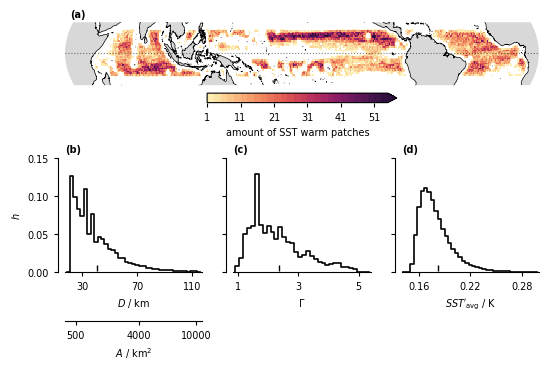

In [ ]:
import matplotlib as mpl

ana_idf = "ngc5004_opv4_w0"

asprat = (10, 7)
style = STYLES['ams']['two_column']
figsize = (style.basewidth, style.basewidth * (asprat[1]/asprat[0]))
plt.style.use(style.mplstyle)

fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(2, 3)

# MAP PLOT
# ------------------------------------------------------------------------------
feature_density = calc_SST_feature_density(featprops[ana_idf])
lon_2d, lat_2d = np.meshgrid(
    feature_density['lon'].values, feature_density['lat'].values,
    )
plot_data = np.ma.masked_less(feature_density['feature_density'].values, 1.0)
ax_top = fig.add_subplot(
    gs[0, :], projection=ccrs.Mollweide(central_longitude=-160)
    )
# build a discrete norm for the 1…35 levels
cmap = cmocean.cm.matter
levels = np.arange(0.999999, 55, 2)
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

cf = ax_top.pcolormesh(
    lon_2d, lat_2d, plot_data,
    cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),
)

ax_top.coastlines(resolution='50m', linewidth=0.5)
ax_top.add_feature(cfeature.LAND, facecolor='gray', alpha=0.3)
for spine in ax_top.spines.values():
    spine.set_visible(False)
lon_line = np.linspace(-180, 180, 361)
ax_top.plot(
    lon_line, np.full_like(lon_line, 0),
    transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
    color='k',
    )
cbar = plt.colorbar(
    cf, ax=ax_top, orientation='horizontal', pad=0.07, shrink=0.4,
    label='amount of SST warm patches', extend='max', ticks=np.arange(1, 53, 10)
)
cbar.ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())


# HISTOGRAMS
# ------------------------------------------------------------------------------
bins = {
    'diameter_km': np.arange(17.5, 120, 2.5), #np.arange(16, 180, 4)
    'ts_ano_detect_mean': np.arange(0.14, 0.304, 0.004),
    'asprat_cart': np.arange(0.85, 5.415, 0.13),
}
xlabels = {
    'diameter_km': 'diameter / km',
    'ts_ano_detect_mean': 'magnitude / K',
    'asprat_cart': 'aspect ratio',
}
xlabels = {
    'diameter_km': '$D$ / km',
    'ts_ano_detect_mean': "$SST\mathrm{'}_{\mathrm{avg}}$ / K",
    'asprat_cart': '$\Gamma$',
}

ax = []
for i, var in enumerate(['diameter_km', 'asprat_cart', 'ts_ano_detect_mean']):
    if i == 0:
        ax.append(fig.add_subplot(gs[1, i]))
    else:
        ax.append(fig.add_subplot(gs[1, i], sharey=ax[0]))
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['bottom'].set_position(('outward', 0))
    ax[i].spines['left'].set_position(('outward', 5))

    counts, bins_hist = np.histogram(featprops[ana_idf][var], bins=bins[var])
    rel_freq = counts/counts.sum()
    ax[i].step(get_bin_centers(bins_hist), rel_freq, color='k', lw=1.2)
    ax[i].legend(frameon=False)
    ax[i].set_xlabel(xlabels[var])
    ax[i].set_xlim(bins[var][0], bins[var][-1])

    # Plot the mean
    ax[i].scatter(featprops[ana_idf][var].mean(), 0.005, color='k', marker='|')

ax_top.text(
    0.01, 1.05, "(a)",
    transform=ax_top.transAxes, fontweight="bold", ha='left', va='bottom',
    )
ax[0].text(
    0.0, 1.03, "(b)",
    transform=ax[0].transAxes, fontweight="bold", ha='left', va='bottom',
    )
ax[1].text(
    0.0, 1.03, "(c)",
    transform=ax[1].transAxes, fontweight="bold", ha='left', va='bottom',
    )
ax[2].text(
    0.0, 1.03, "(d)",
    transform=ax[2].transAxes, fontweight="bold", ha='left', va='bottom',
    )

# Add second x-axis for diameter of SST patches
x_tickpos_new = {'major': [500, 4000, 10000]}
x_ticklabel = {'major': [str(x) for x in x_tickpos_new['major']]}
x_tickpos = {'major': [2*np.sqrt(x/np.pi) for x in x_tickpos_new['major']]}

axis2 = hffig.add_2nd_xaxis(
    ax[0], x_tickpos, x_ticklabel, '$A$ / km$^2$', loc="bottom",
    )
axis2.spines['bottom'].set_position(('outward', 35))

# Make plot nice
ax[0].set_ylabel('$h$')#relative frequency')
ax[0].set_ylim([0, 0.15])
ax[0].set_yticks([0, 0.05, 0.1, 0.15])
ax[0].set_xticks([30, 70, 110])
ax[1].set_xticks([1, 3, 5])
ax[2].set_xticks([0.16, 0.22, 0.28])
ax[1].tick_params(labelleft=False)
ax[2].tick_params(labelleft=False)

plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure02.png')
plt.savefig(str(outpath/outfile), dpi=600)
plt.show()